# Customer Segmentation Using Clustering

## 1. Introduction

Customer segmentation is a common application of unsupervised learning. The
idea is to group customers with similar characteristics and purchasing
behavior, without having predefined customer categories.

In this project, we use the **Customer Segmentation : Clustering** dataset
from Kaggle. The dataset contains information about customers' demographics,
income, spending, purchasing behavior, and interactions with the company's
website and stores.

The goal is to identify meaningful customer segments and then understand what
distinguishes one segment from another.

Two clustering approaches are explored:

- KMeans
- Gaussian Mixture Model (GMM)

After creating the clusters, we analyze their characteristics, visualize the
segments, and translate the results into descriptive customer profiles and
potential business strategies.

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns 

### Data Source

The dataset used in this analysis is the **Customer Segmentation :
Clustering** dataset available on Kaggle.

In [3]:
df = pd.read_csv('../data/customer_segmentation.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 2. Understanding the Dataset

Before applying a clustering algorithm, it is important to understand what
information is available in the dataset.

The variables describe several aspects of customer behavior, including
demographic characteristics, income, spending, online activity, store
purchases, and purchase recency.

Some of the variables used in the analysis are:

- `Age` — customer's age
- `Income` — customer's income
- `Total_Spending` — total amount spent by the customer
- `NumWebPurchases` — number of purchases made through the website
- `NumStorePurchases` — number of purchases made in physical stores
- `NumWebVisitsMonth` — number of visits to the website per month
- `Recency` — number of days since the customer's most recent purchase

These variables give us information about not only how much customers spend,
but also how they interact with the company and which purchasing channels
they use.

In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [7]:
df.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,663,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,31-08-2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.935714,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,23.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.250000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


## 3. Exploratory Data Analysis and Preprocessing

Before applying any clustering algorithm, it is important to first understand
the structure and quality of the data.

The exploratory analysis helps identify the main characteristics of the
customers, relationships between variables, and potential issues that need to
be addressed before modeling.

The preprocessing step then prepares the data for analysis. This includes
checking data types, handling missing values, converting date-related
variables into a usable format, and creating more meaningful variables where
appropriate.

The analysis is not limited to the features that will eventually be used for
clustering. Looking at additional variables, such as education and marital
status, can provide useful context about the customer population and can
later help us interpret the resulting customer segments.

Hence, the data needs to be checked for missing values and other
potential issues.

This is particularly important for clustering because algorithms such as
KMeans and GMM cannot directly work with missing values.

In [8]:
result = df.isna().sum().sort_values(ascending=False)
result 

Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [9]:
result = result[result > 0]
result 

Income    24
dtype: int64

### Handling Missing Values

The dataset contains 24 observations with missing values in the variables
used for clustering.

Since these observations represent only a small portion of the dataset,
they are removed from the analysis rather than imputing their values.

After this step, the remaining observations can be used for the clustering
analysis.

In [10]:
df.dropna(inplace=True)

In [11]:
df.describe(include='all')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216,2216,2216.000000,2216.000000,2216.000000,2216,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,662,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,31-08-2012,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1116,857,NaN,NaN,NaN,12,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5588.353339,1968.820397,NaN,NaN,52247.251354,0.441787,0.505415,NaN,49.012635,305.091606,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,NaN,NaN,25173.076661,0.536896,0.544181,NaN,28.948352,337.327920,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,24.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,174.500000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,505.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['ID'].duplicated().sum()

np.int64(0)

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [15]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [16]:
df['Education'].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [17]:
df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [18]:
df['Dt_Customer'].head(5)

0    04-09-2012
1    08-03-2014
2    21-08-2013
3    10-02-2014
4    19-01-2014
Name: Dt_Customer, dtype: str

In [19]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [20]:
df['Dt_Customer'].head(5)

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[us]

In [21]:
df['Year_Birth'].describe() # min age needs to be investigated

count    2216.000000
mean     1968.820397
std        11.985554
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64

In [22]:
df['Year_Birth'].sort_values().head(20) # Just to see if there are unrealistic ages included 

239     1893
339     1899
192     1900
1950    1940
424     1941
1150    1943
1923    1943
415     1943
39      1943
894     1943
358     1943
519     1944
499     1944
611     1944
494     1944
1270    1944
1413    1944
803     1944
790     1945
103     1945
Name: Year_Birth, dtype: int64

In [23]:
df['Age'] = 2025 - df['Year_Birth']
df['Age'].describe() # we need to investigate the Max age indicated. 

count    2216.000000
mean       56.179603
std        11.985554
min        29.000000
25%        48.000000
50%        55.000000
75%        66.000000
max       132.000000
Name: Age, dtype: float64

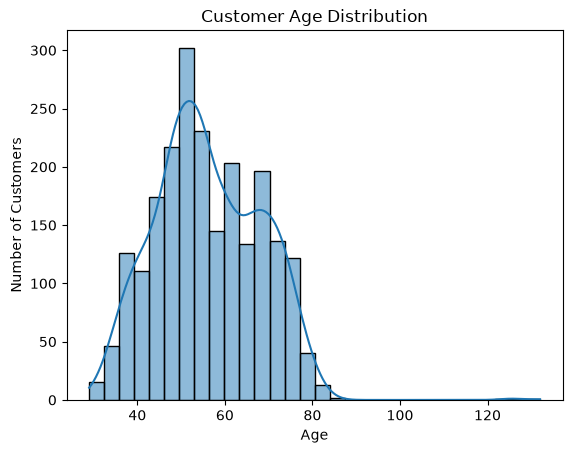

In [24]:
sns.histplot(df["Age"], bins=30, kde=True)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

In [25]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age'],
      dtype='str')

In [26]:
(pd.Timestamp('today'))

Timestamp('2026-09-02 23:22:41.093234')

In [27]:
df['Customer_Since'] = (pd.Timestamp('today') - df['Dt_Customer']).dt.days
df['Customer_Since']

0       5111
1       4561
2       4760
3       4587
4       4609
        ... 
2235    4829
2236    4467
2237    4603
2238    4604
2239    5070
Name: Customer_Since, Length: 2216, dtype: int64

In [28]:
df['Income'].describe()

count      2216.000000
mean      52247.251354
std       25173.076661
min        1730.000000
25%       35303.000000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

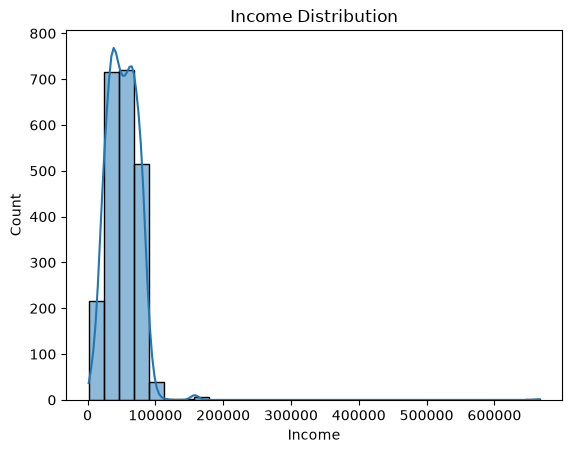

In [29]:
sns.histplot(df['Income'], bins=30, kde=True)
plt.title('Income Distribution')
plt.show()

In [30]:
spend_cols = ['MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']

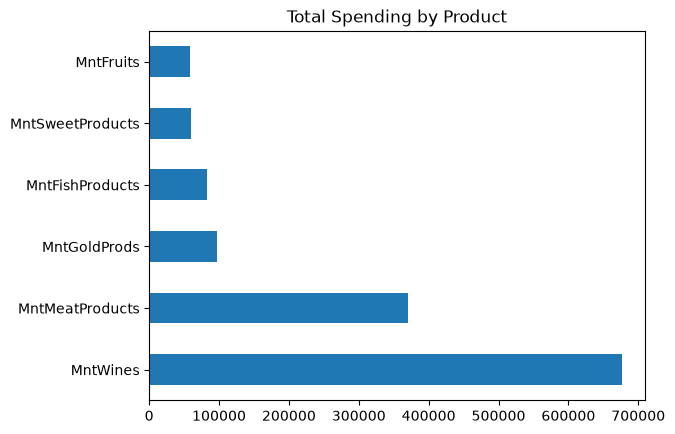

In [31]:
spending = df[spend_cols].sum().sort_values(ascending=False)
spending.plot(kind='barh')
plt.title('Total Spending by Product')
plt.show()

In [32]:
df['Total_Spending'] = df[spend_cols].sum(axis=1)

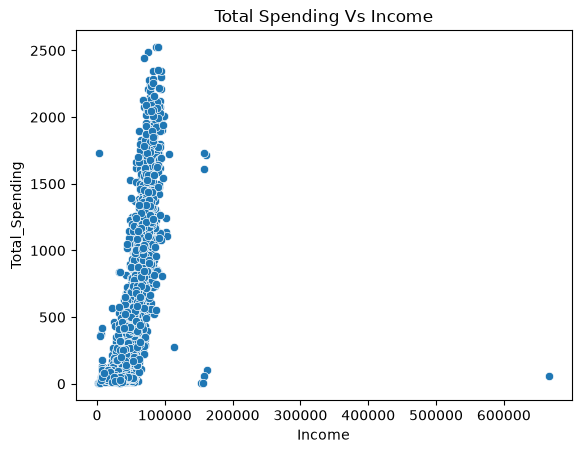

In [33]:
sns.scatterplot(data=df, x="Income", y="Total_Spending")
plt.title('Total Spending Vs Income')
plt.show()

In [34]:
channel_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

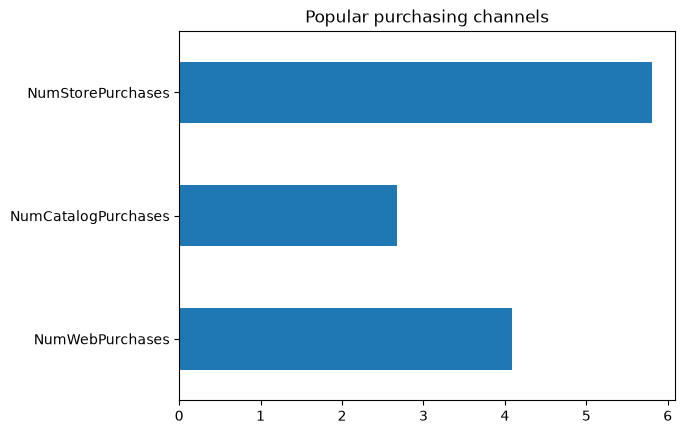

In [35]:
df[channel_cols].mean().plot(kind="barh")
plt.title('Popular purchasing channels')
plt.show()

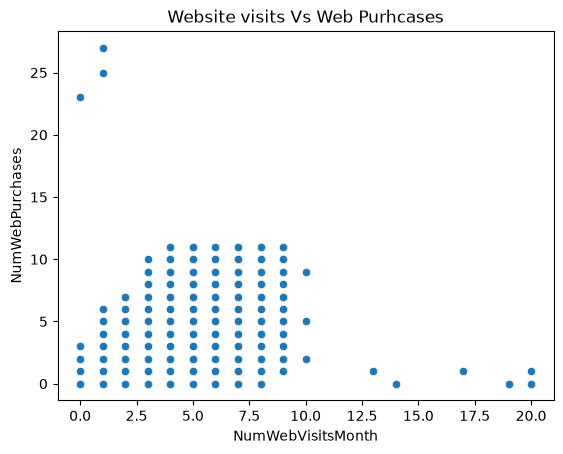

In [36]:
sns.scatterplot(
    data=df,
    x="NumWebVisitsMonth",
    y="NumWebPurchases"
)
plt.title('Website visits Vs Web Purhcases')
plt.show()

In [37]:
df[['NumWebVisitsMonth','NumWebPurchases' ]].corr()

,NumWebVisitsMonth,NumWebPurchases
NumWebVisitsMonth,1.000000,-0.051226
NumWebPurchases,-0.051226,1.000000


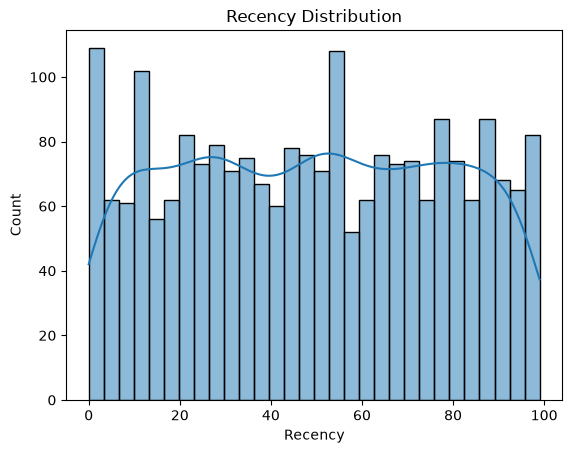

In [38]:
sns.histplot(df["Recency"], bins=30, kde=True)
plt.title('Recency Distribution')
plt.show()

### Recency

The distribution of `Recency` is approximately uniform across its range.
Customers are therefore relatively evenly distributed according to the
number of days since their last purchase, rather than being concentrated
within a particular recency interval.

This suggests that recency may provide useful information for segmentation,
as it can help distinguish recently active customers from customers who have
not purchased for a longer period.

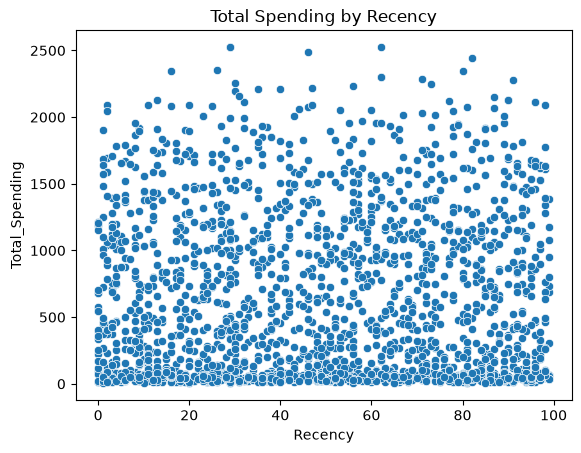

In [39]:
sns.scatterplot(
    data=df,
    x="Recency",
    y="Total_Spending"
)
plt.title('Total Spending by Recency')
plt.show()

### Recency vs Total Spending

The relationship between recency and total spending does not show a strong
linear pattern.

A large concentration of customers has relatively low total spending and is
distributed across almost the entire range of recency values. Higher-spending
customers are less numerous but are also distributed across a broad range of
recency values.

This suggests that recency and spending capture different aspects of
customer behavior. A customer can have high historical spending while also
having a relatively high recency value, indicating that they may represent a
valuable but currently inactive or at-risk customer.

In [40]:
df[["Recency", "Total_Spending"]].corr()

,Recency,Total_Spending
Recency,1.000000,0.020066
Total_Spending,0.020066,1.000000


In [41]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

df[campaign_cols].mean() * 100 # percentage of customers responding to each campaign

AcceptedCmp1     6.407942
AcceptedCmp2     1.353791
AcceptedCmp3     7.355596
AcceptedCmp4     7.400722
AcceptedCmp5     7.310469
Response        15.027076
dtype: float64

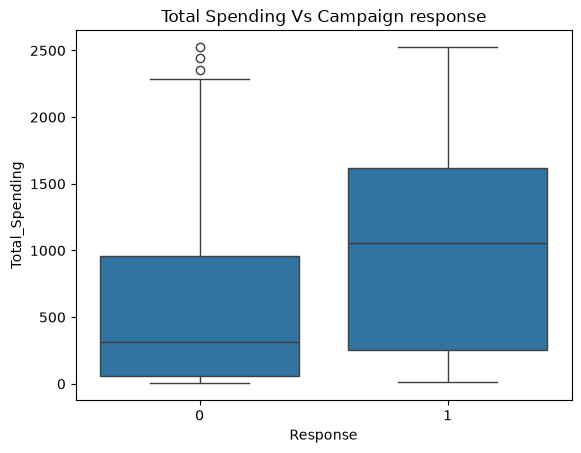

In [42]:
sns.boxplot(
    data=df,
    x="Response",
    y="Total_Spending"
)
plt.title('Total Spending Vs Campaign response')
plt.show()

In [43]:
df["Complain"].value_counts(normalize=True) * 100

Complain
0    99.052347
1     0.947653
Name: proportion, dtype: float64

In [44]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

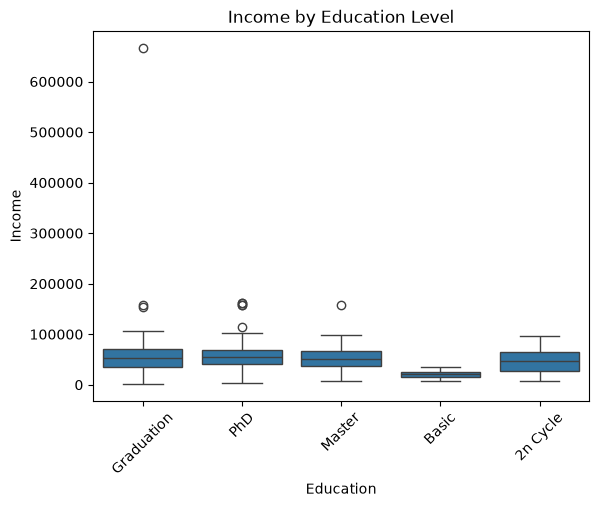

In [45]:
sns.boxplot(x='Education', y='Income', data=df)
plt.xticks(rotation=45)
plt.title('Income by Education Level')
plt.show()

In [46]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

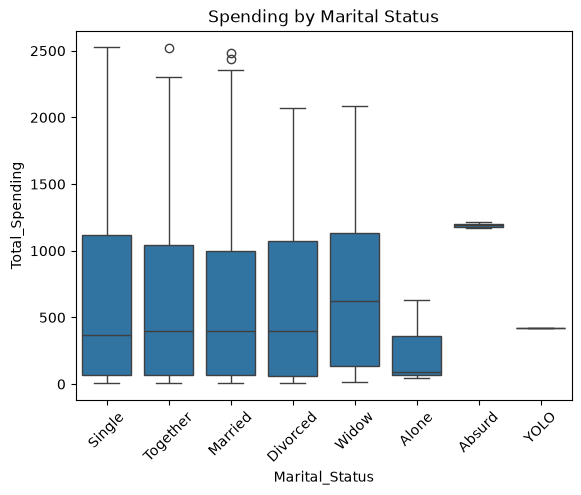

In [47]:
sns.boxplot(x='Marital_Status', y='Total_Spending', data=df)
plt.xticks(rotation=45)
plt.title('Spending by Marital Status')
plt.show()

In [48]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']


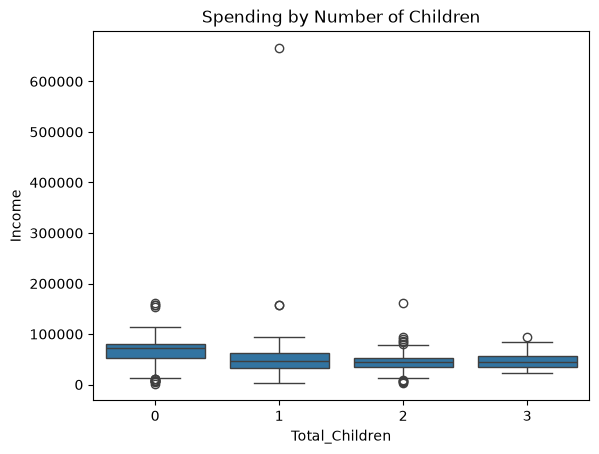

In [49]:
sns.boxplot(
    data=df,
    x="Total_Children",
    y="Income"
)
plt.title('Spending by Number of Children')
plt.show()

In [50]:
corr = df[['Income','Age','Recency','Total_Spending', 'NumWebPurchases', 'NumStorePurchases']].corr()
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


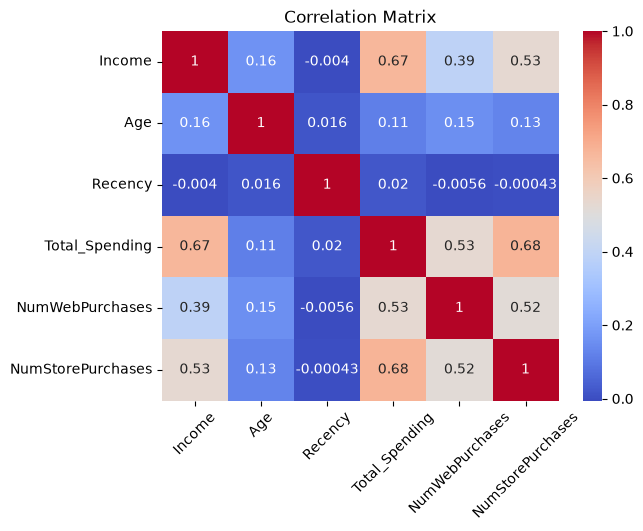

In [51]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

In [52]:
pivot_income = df.pivot_table(values='Income', index='Education', 
                              columns='Marital_Status', aggfunc='mean')

In [53]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


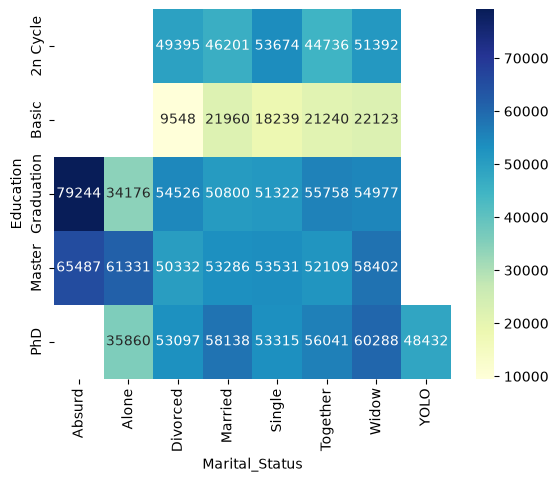

In [54]:
sns.heatmap(data=pivot_income, cmap='YlGnBu', annot=True, fmt='.0f')
plt.show()

In [55]:
group1 = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)     
group1                                                            

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

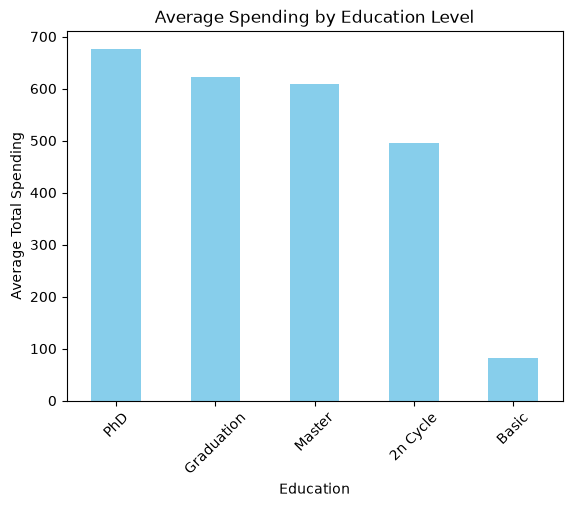

In [56]:
group1.plot(kind='bar', color='skyblue')
plt.title('Average Spending by Education Level')
plt.ylabel('Average Total Spending')
plt.xticks(rotation=45)
plt.show()

In [57]:
bins = [18, 30, 40, 50, 60, 70, 90]

In [58]:
labels = ['18-29', '30-39','40-49','50-59','60-69','70+']

In [59]:
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [60]:
df['AgeGroup']

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, str): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [61]:
group3 = df.groupby('AgeGroup')['Income'].mean()

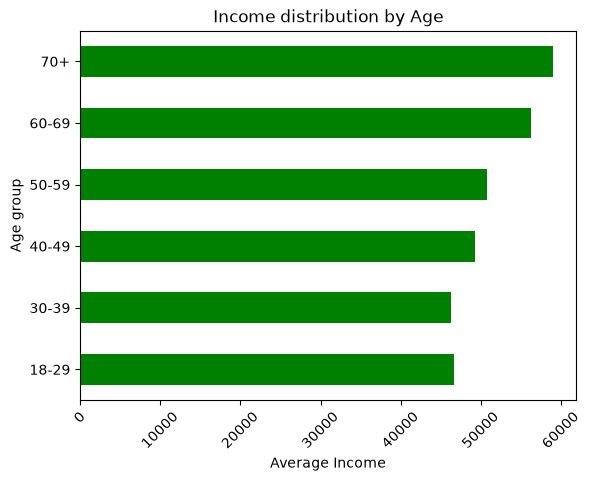

In [62]:
group3.plot(kind='barh', color='green')
plt.title('Income distribution by Age')
plt.xticks(rotation=45)
plt.xlabel('Average Income')
plt.ylabel('Age group')
plt.show()

## 4. Selecting the Features

Not every column in the dataset should be used for clustering.

For example, customer identifiers are useful for identifying individual
customers, but they do not describe customer behavior. Including such
variables could introduce meaningless differences between observations.

The clustering features are therefore selected based on whether they provide
useful information about the customer's demographic profile, spending,
purchasing behavior, or engagement.

Selected Features : ['Age', 'Income', 'Total_Spending','NumWebPurchases','NumStorePurchases','NumWebVisitsMonth','Recency']

In [63]:
features = ['Age', 'Income', 'Total_Spending',
            'NumWebPurchases','NumStorePurchases',
            'NumWebVisitsMonth','Recency']

In [64]:
x = df[features].copy()
x

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


## 5. Feature Scaling

The selected features have very different numerical ranges.

For example, `Income` can contain values in the tens of thousands, while
purchase counts are generally much smaller.

This matters for KMeans because the algorithm uses distances between
observations. Without scaling, variables with larger numerical values could
have a disproportionate influence on the clustering.

The features are therefore standardized using `StandardScaler`.

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [66]:
x_scaled = scaler.fit_transform(x)
x_scaled

array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

## 6. KMeans Clustering

KMeans groups observations by assigning them to the nearest cluster centroid.

The algorithm starts with a number of initial centroids and then repeatedly:

1. Assigns each observation to its nearest centroid.
2. Calculates a new centroid for each cluster.
3. Repeats these steps until the cluster assignments stabilize.

One important parameter is `n_clusters`, which determines how many customer
segments will be created.

The next step is therefore to find a reasonable value for K.

In [67]:
from sklearn.cluster import KMeans

## 7. Choosing the Number of Clusters

There is no universally correct number of clusters for a dataset. Instead,
several values of K can be tested and compared using clustering evaluation
metrics.

Two commonly used approaches are the elbow method and the silhouette score.

### Elbow Method

The elbow method uses KMeans inertia, which measures the sum of squared
distances between observations and their assigned cluster centroids.

As K increases, inertia will generally decrease because the observations are
divided into smaller groups.

The goal is to identify a point where increasing K further produces only a
small improvement. This point is commonly referred to as the "elbow".

In [68]:
Opt_inertia = []
for i in range(2,10):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(x_scaled)
  Opt_inertia.append(kmeans.inertia_)
  print(f'at {i} inertial : {kmeans.inertia_}')
  

at 2 inertial : 10218.620143748783
at 3 inertial : 9303.349676497382
at 4 inertial : 8159.355714963873
at 5 inertial : 7578.217065195124
at 6 inertial : 7102.81896450634
at 7 inertial : 6820.512393778464
at 8 inertial : 6445.565381528359
at 9 inertial : 6224.740490354581


### Silhouette Score

The silhouette score measures how well each observation fits within its own
cluster compared with neighboring clusters.

The score ranges from -1 to 1, with higher values generally indicating
better-defined clusters.

Unlike the elbow method, which focuses on within-cluster compactness, the
silhouette score also considers how well-separated the clusters are.

In [69]:
from sklearn.metrics import silhouette_score

In [70]:
kmeans_silhouette = []
kmeans_inertias = []
for i in range(2,10):
  kmeans = KMeans(n_clusters=i, random_state=42)
  labels = kmeans.fit_predict(x_scaled)
  kmeans_inertias.append(kmeans.inertia_)
  kmeans_silhouette.append(
    silhouette_score(x_scaled, labels)
  )
  

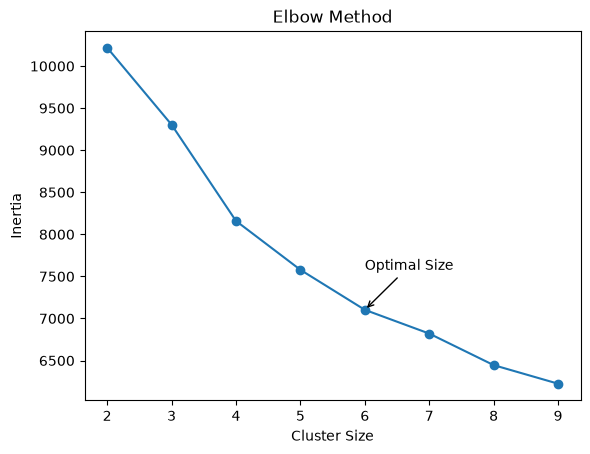

In [71]:
plt.plot(range(2,10), kmeans_inertias, marker='o')
plt.xlabel('Cluster Size')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.annotate('Optimal Size', 
             xy=(6,7102), 
             xytext=(6, 7578), 
             arrowprops=dict(arrowstyle='->'))
plt.show()

In [72]:
kmeans_inertias

[10218.620143748783,
 9303.349676497384,
 8159.355714963873,
 7578.2170651951255,
 7102.81896450634,
 6820.512393778464,
 6445.565381528358,
 6224.74049035458]

In [73]:
kmeans_silhouette

[0.3215123349066069,
 0.20771292705132444,
 0.1948047355187892,
 0.19220367896713528,
 0.1847525162652589,
 0.17643746486012,
 0.18326098891637232,
 0.1824149562750196]

### Choosing the Number of Clusters

The elbow method and silhouette score do not point to the same number of
clusters, so there is no single value of K that is clearly preferred by both
methods.

The elbow curve shows a sharp decrease in inertia as K increases from 2 to 5.
After K = 5, the improvement becomes much smaller and the curve starts to
flatten. This suggests that adding more clusters beyond this point provides
only a limited reduction in within-cluster variation. The elbow is therefore
around K = 5–6, with K = 6 selected for the analysis.

The silhouette score gives a different result, with its highest value at
K = 2 as shown in Figure below. This indicates that two clusters provide the strongest separation
according to the silhouette criterion. However, using only two clusters would
result in a very broad segmentation and would not capture some of the more
specific differences in customer behavior visible in the data.

Because the two methods evaluate different aspects of clustering, the final
choice of K should not be based on either metric alone. The elbow method,
silhouette score, cluster profiles, and the practical usefulness of the
resulting customer segments are considered together.

In [74]:
best_k = range(2,10)[kmeans_silhouette.index(max(kmeans_silhouette))]
best_k

2

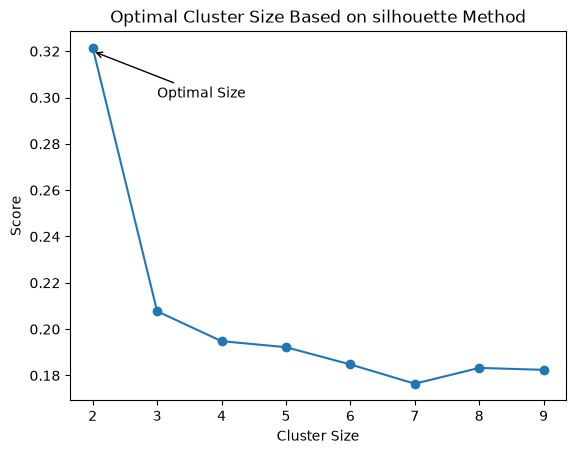

In [75]:
plt.plot(range(2,10), kmeans_silhouette, marker='o')
plt.title('Optimal Cluster Size Based on silhouette Method')
plt.ylabel('Score')
plt.xlabel('Cluster Size')
plt.annotate('Optimal Size', 
             xy=(best_k,0.32), 
             xytext=(3, 0.3), 
             arrowprops=dict(arrowstyle='->'))
plt.show()

## 8. KMeans Customer Segmentation

After evaluating several values of K=6, KMeans is fitted using the selected
number of clusters.

The resulting cluster labels are added to the dataset so that the behavior
and characteristics of each customer segment can be examined.

In [127]:
optimal_cluster_size = 6 #Elbow Method 
kmeans = KMeans(n_clusters=optimal_cluster_size)
labels = kmeans.fit_predict(x_scaled)
df['Cluster'] = labels

In [133]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
evaluation_metrics = []
evaluation_metrics.append({
    "Model": "K-Means",
    "Clusters": optimal_cluster_size,
    "Silhouette Score": silhouette_score(x_scaled, labels),
    "Davies-Bouldin Index": davies_bouldin_score(x_scaled, labels),
    "Calinski-Harabasz Score": calinski_harabasz_score(x_scaled, labels),
    "Inertia": kmeans.inertia_,
})
evaluation_metrics

[{'Model': 'K-Means',
  'Clusters': 6,
  'Silhouette Score': 0.1861830211668993,
  'Davies-Bouldin Index': 1.614996802810536,
  'Calinski-Harabasz Score': 524.3959816875207,
  'Inertia': 7094.714930444478}]

## 9. Understanding the Customer Segments

The cluster numbers generated by KMeans are arbitrary. Cluster 0 does not
represent a particular type of customer simply because it is labeled 0.

To interpret the clusters, the average values of the main customer
characteristics are calculated for each group.

This allows us to compare the segments in terms of age, income, spending,
purchasing channels, website activity, and recency.

In [77]:
cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,47.795556,31663.164444,104.680000,2.140000,3.131111,6.820000,26.966667
1,69.478528,73498.975460,1200.052147,4.644172,8.512270,2.776074,52.325153
2,58.595122,60147.102439,905.824390,8.026829,7.951220,6.390244,46.356098
3,46.254545,78240.869697,1300.603030,4.581818,8.587879,2.657576,49.763636
4,51.875895,35149.582339,133.410501,2.436754,3.441527,6.582339,79.369928
5,68.725979,43997.669039,179.608541,2.676157,4.039146,5.544484,38.202847


### Giving the Clusters Meaning

The numerical cluster labels are replaced with descriptive names based on
the characteristics observed in each group.

For example, a cluster with high spending and strong activity across both
online and physical stores can reasonably be described as a
**High-Value Omnichannel Customer**.

The names are descriptive rather than model-generated; they are used to make
the results easier to interpret from a business perspective.

In [78]:
cluster_names = {
    0: "Recent Low-Value Customers",
    1: "High-Value At-Risk Customers",
    2: "High-Value Store Loyalists",
    3: "Dormant / Disengaged Customers",
    4: "High-Value Omnichannel Customers",
    5: "Low-Engagement Mature Customers"
}

In [79]:
df['Cluster_Names'] = df['Cluster'].map(cluster_names)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Customer_Since,Total_Spending,Total_Children,AgeGroup,Cluster,Cluster_Names
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,5111,1617,0,60-69,2,High-Value Store Loyalists
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,4561,27,2,70+,5,Low-Engagement Mature Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,4760,776,0,50-59,2,High-Value Store Loyalists
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,41,4587,53,1,40-49,0,Recent Low-Value Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,44,4609,422,1,40-49,4,High-Value Omnichannel Customers


## 10. Customer Segment Distribution

Before looking at the characteristics of individual segments, it is useful
to understand how the customers are distributed among them.

The chart below shows both the number and percentage of customers belonging
to each segment.

In [80]:
df['Cluster_Names'].value_counts()

Cluster_Names
Recent Low-Value Customers          450
High-Value Omnichannel Customers    419
High-Value Store Loyalists          410
Dormant / Disengaged Customers      330
High-Value At-Risk Customers        326
Low-Engagement Mature Customers     281
Name: count, dtype: int64

In [81]:
cluster_counts = df["Cluster_Names"].value_counts()

cluster_percentage = (
    cluster_counts / len(df) * 100
).round(1)

cluster_summary = pd.DataFrame({
    "Customers": cluster_counts,
    "Percentage (%)": cluster_percentage
})

cluster_summary

,Customers,Percentage (%)
Cluster_Names,,
Recent Low-Value Customers,450,20.3
High-Value Omnichannel Customers,419,18.9
High-Value Store Loyalists,410,18.5
Dormant / Disengaged Customers,330,14.9
High-Value At-Risk Customers,326,14.7
Low-Engagement Mature Customers,281,12.7


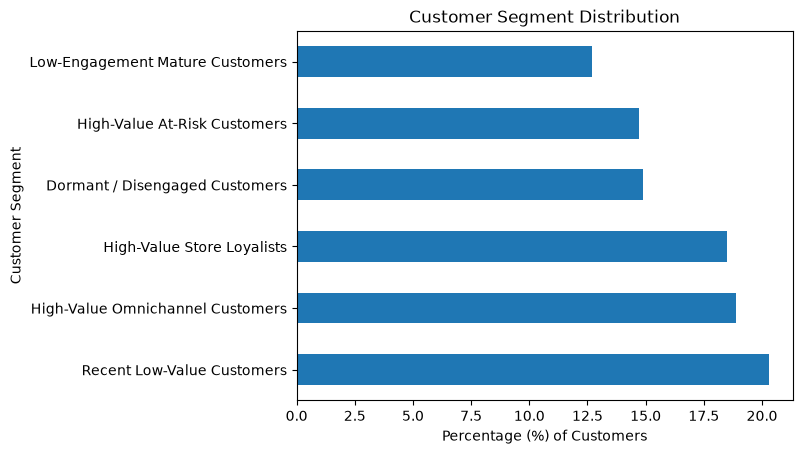

In [82]:
cluster_summary['Percentage (%)'].plot(kind='barh')
plt.xlabel('Percentage (%) of Customers')
plt.ylabel("Customer Segment")
plt.title("Customer Segment Distribution")
plt.show()

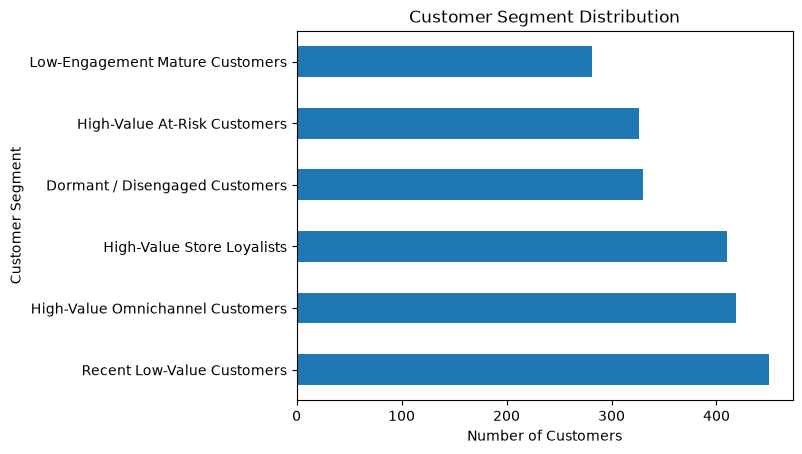

In [83]:
cluster_summary['Customers'].plot(kind='barh')
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.title("Customer Segment Distribution")
plt.show()

## 11. Visualizing the Clusters with PCA

The clustering itself was performed using all selected features. However,
these features exist in a multidimensional space, which cannot be directly
visualized in a standard two-dimensional scatter plot.

Principal Component Analysis (PCA) can be used to project the data onto two
dimensions while retaining as much of the variation in the original data as
possible.

Here, PCA is used only for visualization. It is not used to perform the
clustering.

The resulting scatter plot provides a simplified view of how the customer
segments are distributed and whether they appear to overlap or separate from
one another.

In [84]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_data = pca.fit_transform(x_scaled)
df['PCA1'], df['PCA2'] = pca_data[:,0],pca_data[:,1]
pca.explained_variance_ratio_


array([0.43281928, 0.1441598 ])

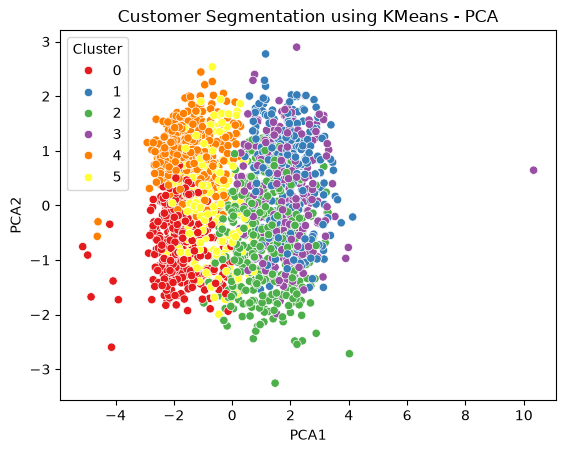

In [85]:
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segmentation using KMeans - PCA')
plt.show()

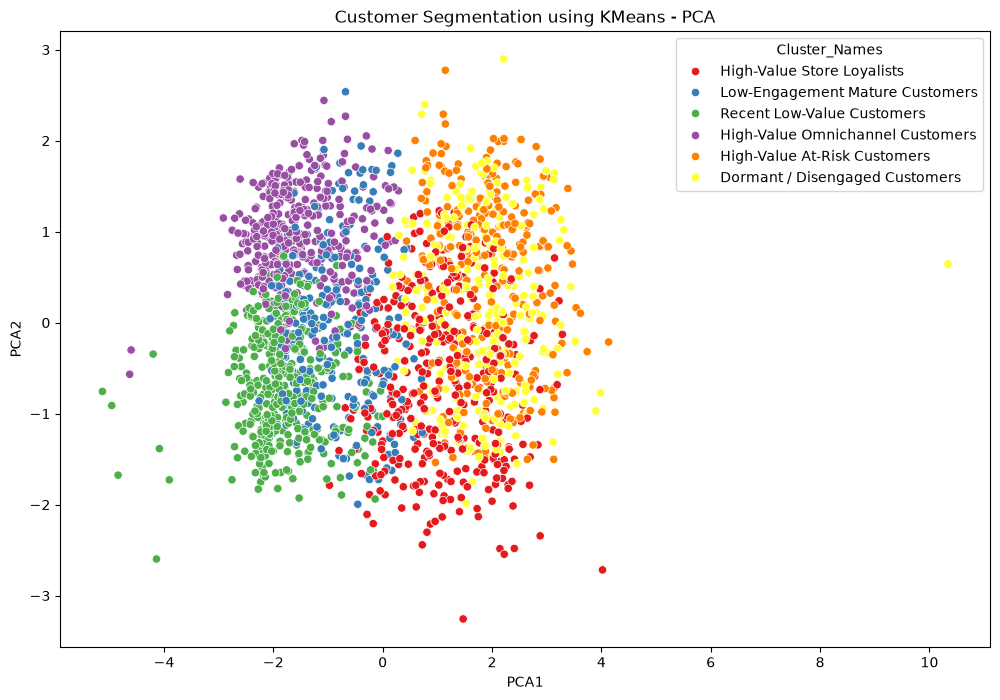

In [86]:
fig = plt.figure(figsize=(12,8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Names', data=df, palette='Set1')
plt.title('Customer Segmentation using KMeans - PCA')
plt.show()

## 12. Cluster Profile Heatmap

Averages alone can make it difficult to compare several features at the same
time, particularly because the features have different scales.

A standardized cluster profile is therefore used to create a heatmap.

Values above zero indicate that the cluster is above the average across
clusters for that feature, while negative values indicate below-average
values.

This makes it easier to identify the characteristics that distinguish each
customer segment.

In [87]:
cluster_profile = df.groupby('Cluster_Names')[features].mean()
cluster_profile

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster_Names,,,,,,,
Dormant / Disengaged Customers,46.254545,78240.869697,1300.603030,4.581818,8.587879,2.657576,49.763636
High-Value At-Risk Customers,69.478528,73498.975460,1200.052147,4.644172,8.512270,2.776074,52.325153
High-Value Omnichannel Customers,51.875895,35149.582339,133.410501,2.436754,3.441527,6.582339,79.369928
High-Value Store Loyalists,58.595122,60147.102439,905.824390,8.026829,7.951220,6.390244,46.356098
Low-Engagement Mature Customers,68.725979,43997.669039,179.608541,2.676157,4.039146,5.544484,38.202847
Recent Low-Value Customers,47.795556,31663.164444,104.680000,2.140000,3.131111,6.820000,26.966667


In [88]:
scaled_cluster = StandardScaler().fit_transform(cluster_profile)

In [89]:
scaled_cluster = pd.DataFrame(scaled_cluster, index=cluster_profile.index, columns=cluster_profile.columns)
scaled_cluster

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster_Names,,,,,,,
Dormant / Disengaged Customers,-1.164875,1.353339,1.294168,0.245802,1.088246,-1.411767,0.058178
High-Value At-Risk Customers,1.324731,1.090955,1.097965,0.276607,1.057126,-1.344062,0.217918
High-Value Omnichannel Customers,-0.562267,-1.031041,-0.983354,-0.813955,-1.029929,0.830696,1.904467
High-Value Store Loyalists,0.158032,0.352152,0.523844,1.947791,0.826205,0.720940,-0.154321
Low-Engagement Mature Customers,1.244058,-0.541448,-0.893208,-0.695680,-0.783956,0.237705,-0.662769
Recent Low-Value Customers,-0.999679,-1.223956,-1.039415,-0.960565,-1.157692,0.966487,-1.363472


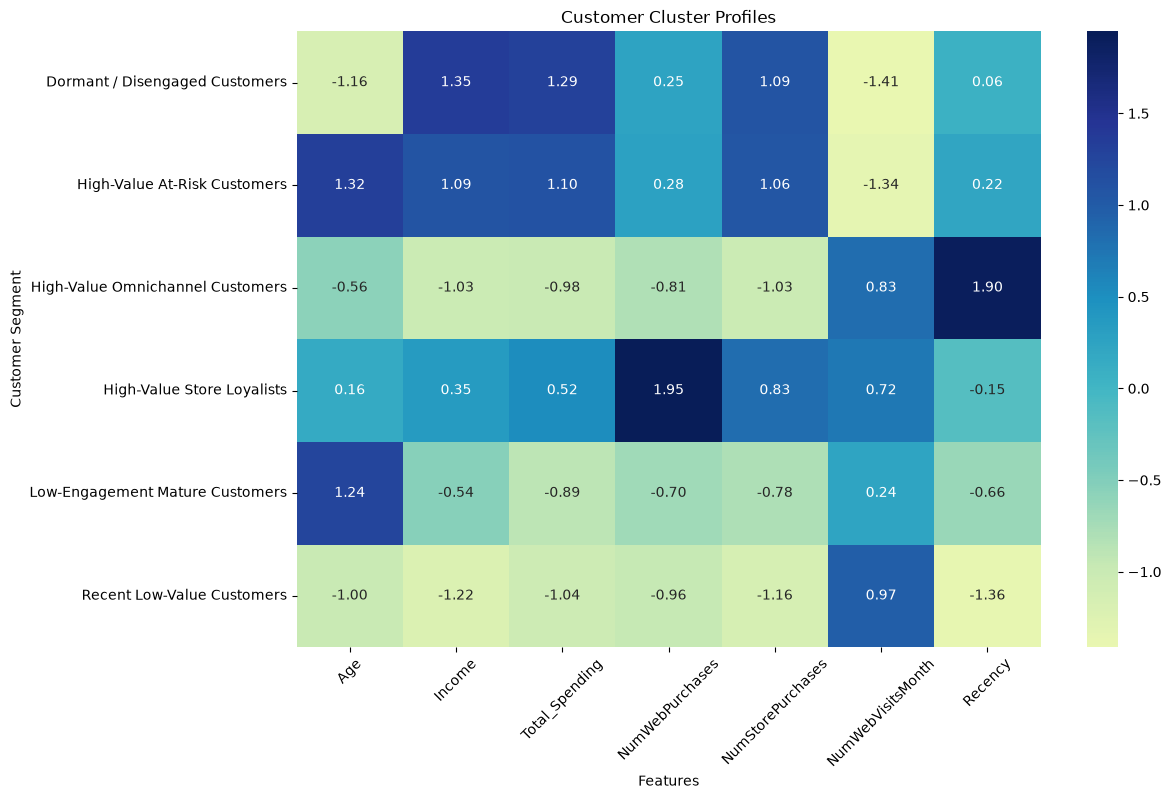

In [90]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    scaled_cluster,
    annot=True,
    fmt=".2f",
    cmap='YlGnBu',
    center=0
)

plt.title("Customer Cluster Profiles")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.ylabel("Customer Segment")
plt.show()

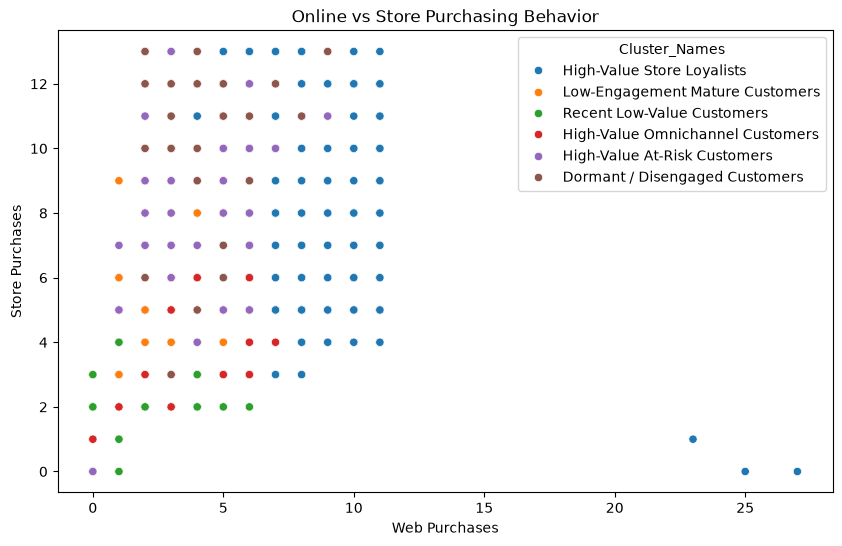

In [91]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(
  data = df, 
  x='NumWebPurchases', 
  y='NumStorePurchases', 
  hue='Cluster_Names'
)
plt.title("Online vs Store Purchasing Behavior")
plt.xlabel("Web Purchases")
plt.ylabel("Store Purchases")
plt.show()

## 13. Gaussian Mixture Model

KMeans assumes that each observation belongs to one cluster based on its
distance from a cluster centroid.

A Gaussian Mixture Model provides a different approach. Instead of assigning
customers purely according to distance, GMM models the data as a mixture of
Gaussian distributions.

An additional advantage is that GMM provides a probability of belonging to
each cluster. This can be useful when a customer's behavior does not clearly
belong to only one segment.

Lets see a sample implementation of GMM with 5 component mixtures. 

In [92]:
from sklearn.mixture import GaussianMixture

In [93]:
import numpy as np 
np.set_printoptions(suppress=True, precision=2)

## 14. Choosing the Number of GMM Components

Unlike KMeans, where the elbow and silhouette methods are commonly used to
evaluate K, GMM can be evaluated using likelihood-based criteria such as AIC
and BIC.

Both criteria balance model fit with model complexity, with lower values
indicating a better trade-off.

BIC applies a stronger penalty for model complexity than AIC, making it useful
when we want to avoid adding unnecessary Gaussian components.

In [94]:
gmm_score = []

for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(x_scaled)

    gmm_score.append({
        "k": k,
        "AIC": gmm.aic(x_scaled),
        "BIC": gmm.bic(x_scaled),
        "Silhouette": silhouette_score(x_scaled, labels)
    })

In [95]:
gmm_aic = [obj['AIC'] for obj in gmm_score]
gmm_bic = [obj['BIC'] for obj in gmm_score]
gmm_sil = [obj['Silhouette'] for obj in gmm_score]


In [96]:
#Optimal cluster in GMM using Silhouette Method 
best_k_gmm_sil = range(2,11)[gmm_sil.index(max(gmm_sil))]
best_k_gmm_sil

2

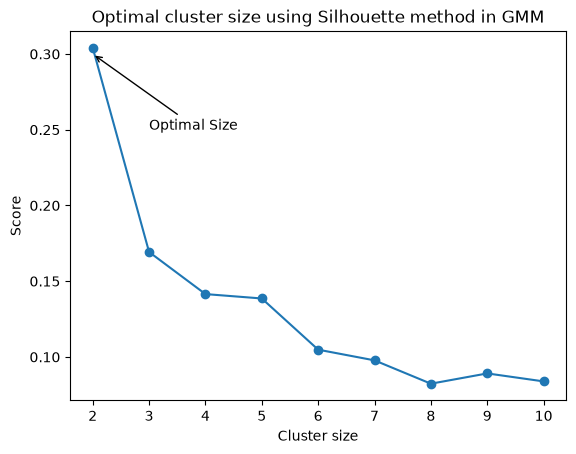

In [97]:
plt.plot(range(2,11), gmm_sil,label='GMM_Silhouette Score', marker='o')
plt.title('Optimal cluster size using Silhouette method in GMM')
plt.ylabel('Score')
plt.annotate('Optimal Size', 
             xy=(best_k_gmm_sil,0.3), 
             xytext=(3, 0.25), 
             arrowprops=dict(arrowstyle='->'))
plt.xlabel('Cluster size')
plt.show()

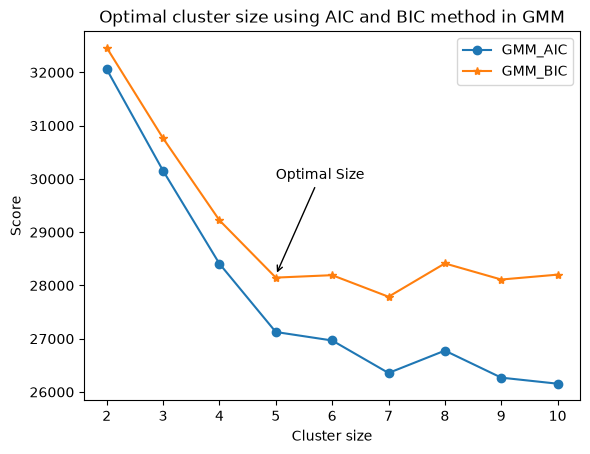

In [98]:
plt.plot(range(2,11), gmm_aic,label='GMM_AIC', marker='o')
plt.plot(range(2,11), gmm_bic, label='GMM_BIC', marker='*')
plt.legend()
plt.title('Optimal cluster size using AIC and BIC method in GMM')
plt.ylabel('Score')
plt.xlabel('Cluster size')
plt.annotate('Optimal Size', 
             xy=(5,gmm_bic[4]), 
             xytext=(5, 30000), 
             arrowprops=dict(arrowstyle='->'))
plt.show()

### Selecting the Final Number of Components

The BIC reaches its minimum at 7 components. However, the improvement in BIC
becomes relatively small after approximately 5 components.

Therefore, the choice between 5 and 7 components should not be based on BIC
alone. The Silhouette Method still prefers a cluster size of 2 as in case of the KMeans. However, 
for the final optimal cluster size,  the cluster sizes, profile differences, and business
interpretability are also considered before selecting the final model. In contrast to the KMeans (k=6), 
a cluster size of k=5 is selected for GMM

In [130]:
gmm_optimal_cluster_size = 5
gmm = GaussianMixture(n_components=gmm_optimal_cluster_size, random_state=42)
gmm_lables = gmm.fit_predict(x_scaled)
df['GMM_Cluster'] = gmm_lables
gmm_lables

array([1, 0, 1, ..., 3, 1, 2], shape=(2216,))

In [134]:
evaluation_metrics.append({
    "Model": "GMM",
    "Clusters": gmm_optimal_cluster_size,
    "Silhouette Score": silhouette_score(x_scaled, gmm_lables),
    "Davies-Bouldin Index": davies_bouldin_score(x_scaled, gmm_lables),
    "Calinski-Harabasz Score": calinski_harabasz_score(x_scaled, gmm_lables),
    "Inertia": None,
    "AIC": gmm.aic(x_scaled),
    "BIC": gmm.bic(x_scaled)
})
evaluation_df = pd.DataFrame(evaluation_metrics)
evaluation_df.to_csv('../data/model_evaluation.csv', index=False)


In [100]:
df['GMM_Cluster'].value_counts()

# ***Note****: The fifth GMM component contains only 10 customers, making it a very small
# segment compared with the other groups. Later, We will try to investigate it in detail. 


GMM_Cluster
1    782
0    703
2    581
3    140
4     10
Name: count, dtype: int64

### Probabilistic Cluster Membership

Unlike KMeans, GMM does not only assign each customer to a single cluster.
It also provides the probability that a customer belongs to each cluster.

Each row below represents one customer, and each value represents the
probability of membership in one of the five GMM clusters. The probabilities
for each customer sum to 1.

For example, the first customer has a 64% probability of belonging to
Cluster 1 and a 36% probability of belonging to Cluster 3, indicating that
their characteristics are somewhat shared between these two segments.

In [101]:
probabilities = gmm.predict_proba(x_scaled)
probabilities[:5]

array([[0.  , 0.64, 0.  , 0.36, 0.  ],
       [0.91, 0.  , 0.09, 0.  , 0.  ],
       [0.  , 0.75, 0.23, 0.02, 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.01, 0.99, 0.  , 0.  ]])

In [102]:
gmm.aic(x_scaled), gmm.bic(x_scaled)

(27125.978858318034, 28146.89802788626)

In [103]:
gmm.aic(x_scaled), gmm.bic(x_scaled)

(27125.978858318034, 28146.89802788626)

### Cluster Assignment Confidence

The highest probability for each customer can be used as a simple measure of
how confident the model is about that customer's cluster assignment.

For example, if the probabilities are:

[0.00, 0.64, 0.00, 0.36, 0.00]

the model assigns the customer to Cluster 1, with a confidence of 64%.

A customer with a probability close to 1 has a clear cluster membership,
while a customer with similar probabilities across two or more clusters has
more ambiguous characteristics.

In [104]:
probabilities = gmm.predict_proba(x_scaled)

df["GMM_Confidence"] = probabilities.max(axis=1)
df["GMM_Confidence"].describe()

count    2216.000000
mean        0.945369
std         0.100192
min         0.430011
25%         0.949256
50%         0.988217
75%         0.998191
max         1.000000
Name: GMM_Confidence, dtype: float64

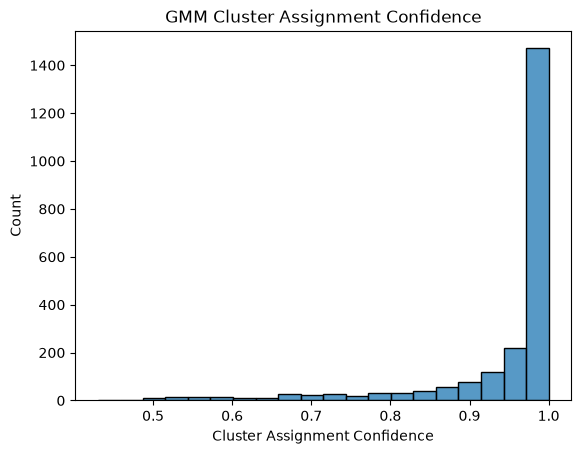

In [105]:
sns.histplot(
    df["GMM_Confidence"],
    bins=20
)

plt.xlabel("Cluster Assignment Confidence")
plt.title("GMM Cluster Assignment Confidence")
plt.show()

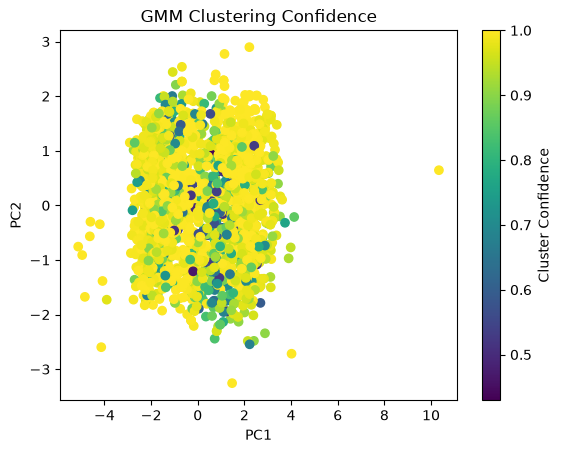

In [106]:
confidence = probabilities.max(axis=1)

plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=confidence
)

plt.colorbar(label="Cluster Confidence")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM Clustering Confidence")
plt.show()

### Naming the GMM Customer Segments

The GMM model assigns each customer to one of five components, but the
component numbers themselves do not have any meaningful interpretation.

To make the results easier to understand, each component is given a
descriptive name based on its average income, spending, purchasing behavior,
and website activity.

The resulting customer profiles are:

- **Low-Value Customers** — relatively high website activity but very low
  spending and purchasing activity.

- **High-Value Store Customers** — high spending with particularly strong
  purchasing activity through physical stores.

- **Mid-Value Active Customers** — moderate spending combined with relatively
  active online browsing and purchasing.

- **High-Value Omnichannel Customers** — high spending with strong activity
  across both online and physical stores.

- **High-Potential Underengaged Customers** — exceptionally high income but
  relatively low spending and engagement, suggesting a potentially valuable
  group that is currently underengaged.

These names are descriptive labels based on the observed cluster profiles;
they are not produced automatically by the GMM model.

In [107]:
gmm_cluster_names = {
    0: "Low-Value Customers", # high website visist but very low spending
    1: "High-Value Store Customers", # high spending + strong store purchasing 
    2: "Mid-Value Active Customers", # moderate spending + active online browsing  
    3: "High-Value Omnichannel Customers", # High spending + strong online / stroe activity 
    4: "High-Potential Underengaged Customers" # Extreme high income but very low engagment 
}

In [108]:
df['GMM_Cluster_Names'] = df['GMM_Cluster'].map(gmm_cluster_names)
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_Spending,Total_Children,AgeGroup,Cluster,Cluster_Names,PCA1,PCA2,GMM_Cluster,GMM_Confidence,GMM_Cluster_Names
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1617,0,60-69,2,High-Value Store Loyalists,1.107519,-0.211760,1,0.639299,High-Value Store Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,27,2,70+,5,Low-Engagement Mature Customers,-1.336734,0.269839,0,0.908660,Low-Value Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,776,0,50-59,2,High-Value Store Loyalists,1.882277,-1.014161,1,0.746566,High-Value Store Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,53,1,40-49,0,Recent Low-Value Customers,-1.784359,-0.704928,0,0.995116,Low-Value Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,422,1,40-49,4,High-Value Omnichannel Customers,0.020363,1.235265,2,0.990352,Mid-Value Active Customers


In [109]:
df.rename(columns={"Cluster_Names": 'KMeans_Cluster_Names'}, inplace=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_Spending,Total_Children,AgeGroup,Cluster,KMeans_Cluster_Names,PCA1,PCA2,GMM_Cluster,GMM_Confidence,GMM_Cluster_Names
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1617,0,60-69,2,High-Value Store Loyalists,1.107519,-0.211760,1,0.639299,High-Value Store Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,27,2,70+,5,Low-Engagement Mature Customers,-1.336734,0.269839,0,0.908660,Low-Value Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,776,0,50-59,2,High-Value Store Loyalists,1.882277,-1.014161,1,0.746566,High-Value Store Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,53,1,40-49,0,Recent Low-Value Customers,-1.784359,-0.704928,0,0.995116,Low-Value Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,422,1,40-49,4,High-Value Omnichannel Customers,0.020363,1.235265,2,0.990352,Mid-Value Active Customers


In [110]:
df.rename(columns={"kmeans_Cluster_Names": 'KMeans_Cluster_Names'}, inplace=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_Spending,Total_Children,AgeGroup,Cluster,KMeans_Cluster_Names,PCA1,PCA2,GMM_Cluster,GMM_Confidence,GMM_Cluster_Names
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,1617,0,60-69,2,High-Value Store Loyalists,1.107519,-0.211760,1,0.639299,High-Value Store Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,27,2,70+,5,Low-Engagement Mature Customers,-1.336734,0.269839,0,0.908660,Low-Value Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,776,0,50-59,2,High-Value Store Loyalists,1.882277,-1.014161,1,0.746566,High-Value Store Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,53,1,40-49,0,Recent Low-Value Customers,-1.784359,-0.704928,0,0.995116,Low-Value Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,422,1,40-49,4,High-Value Omnichannel Customers,0.020363,1.235265,2,0.990352,Mid-Value Active Customers


In [111]:
gmm_profile = df.groupby("GMM_Cluster_Names")[
   features
].mean()
gmm_profile

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
GMM_Cluster_Names,,,,,,,
High-Potential Underengaged Customers,53.100000,180580.500000,735.300000,0.500000,1.500000,1.200000,43.700000
High-Value Omnichannel Customers,56.428571,64970.671429,1171.971429,4.985714,7.450000,7.150000,46.421429
High-Value Store Customers,58.349105,70968.377238,1215.424552,5.773657,8.668798,3.358056,50.234015
Low-Value Customers,52.536273,31095.015647,50.018492,1.596017,2.873400,6.446657,48.466572
Mid-Value Active Customers,57.660929,47368.576592,323.967298,4.669535,5.160069,6.223752,48.745267


In [112]:
gmm_profile_scaled = StandardScaler().fit_transform(gmm_profile)
gmm_profile_scaled = pd.DataFrame(gmm_profile_scaled, index=gmm_profile.index, columns=gmm_profile.columns)
gmm_profile_scaled

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
GMM_Cluster_Names,,,,,,,
High-Potential Underengaged Customers,-1.060372,1.928358,0.078347,-1.453543,-1.349703,-1.634963,-1.686571
High-Value Omnichannel Customers,0.343031,-0.266254,1.029640,0.716245,0.862344,1.011621,-0.482969
High-Value Store Customers,1.152772,-0.152400,1.124303,1.097381,1.315460,-0.675051,1.203217
Low-Value Customers,-1.298053,-0.909312,-1.414545,-0.923388,-0.839111,0.698771,0.421533
Mid-Value Active Customers,0.862622,-0.600393,-0.817745,0.563306,0.011010,0.599622,0.544791


### Inspecting the High-Potential Underengaged Customers

The fifth GMM component contains only 10 customers, making it a very small
segment compared with the other groups.

These customers are characterized by exceptionally high income but relatively
low spending and engagement. Because of their unusual profile, it is useful
to inspect these observations individually rather than relying only on the
cluster averages.

The following table shows the 10 customers assigned to this segment.

In [113]:
df['GMM_Cluster'].value_counts()

GMM_Cluster
1    782
0    703
2    581
3    140
4     10
Name: count, dtype: int64

In [114]:
df[df['GMM_Cluster'] == 4]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Total_Spending,Total_Children,AgeGroup,Cluster,KMeans_Cluster_Names,PCA1,PCA2,GMM_Cluster,GMM_Confidence,GMM_Cluster_Names
21,5376,1979,Graduation,Married,2447.0,1,0,2013-01-06,42,1,...,1730,1,40-49,0,Recent Low-Value Customers,-0.839963,0.628101,4,1.000000,High-Potential Underengaged Customers
164,8475,1973,PhD,Married,157243.0,0,1,2014-03-01,98,20,...,1608,1,50-59,3,Dormant / Disengaged Customers,2.211558,2.897761,4,1.000000,High-Potential Underengaged Customers
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,...,107,2,40-49,3,Dormant / Disengaged Customers,0.980855,0.711449,4,1.000000,High-Potential Underengaged Customers
619,10862,1960,Master,Married,30522.0,0,1,2012-08-17,6,179,...,326,1,60-69,5,Low-Engagement Mature Customers,0.018062,-0.644142,4,0.988859,High-Potential Underengaged Customers
655,5555,1975,Graduation,Divorced,153924.0,0,0,2014-02-07,81,1,...,6,0,40-49,3,Dormant / Disengaged Customers,0.769659,2.398696,4,1.000000,High-Potential Underengaged Customers
687,1501,1982,PhD,Married,160803.0,0,0,2012-08-04,21,55,...,1717,0,40-49,3,Dormant / Disengaged Customers,2.386198,0.403283,4,1.000000,High-Potential Underengaged Customers
1300,5336,1971,Master,Together,157733.0,1,0,2013-06-04,37,39,...,59,1,50-59,3,Dormant / Disengaged Customers,1.048017,0.826545,4,1.000000,High-Potential Underengaged Customers
1653,4931,1977,Graduation,Together,157146.0,0,0,2013-04-29,13,1,...,1730,0,40-49,3,Dormant / Disengaged Customers,2.087650,0.099967,4,1.000000,High-Potential Underengaged Customers
2132,11181,1949,PhD,Married,156924.0,0,0,2013-08-29,85,2,...,8,0,70+,1,High-Value At-Risk Customers,1.146243,2.773473,4,1.000000,High-Potential Underengaged Customers
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,...,62,1,40-49,3,Dormant / Disengaged Customers,10.337382,0.644223,4,1.000000,High-Potential Underengaged Customers


In [115]:
df[df['GMM_Cluster'] == 4][features + ['KMeans_Cluster_Names', 'GMM_Cluster_Names']]

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency,KMeans_Cluster_Names,GMM_Cluster_Names
21,46,2447.0,1730,0,0,1,42,Recent Low-Value Customers,High-Potential Underengaged Customers
164,52,157243.0,1608,0,0,0,98,Dormant / Disengaged Customers,High-Potential Underengaged Customers
617,49,162397.0,107,0,1,1,31,Dormant / Disengaged Customers,High-Potential Underengaged Customers
619,65,30522.0,326,1,9,2,6,Low-Engagement Mature Customers,High-Potential Underengaged Customers
655,50,153924.0,6,0,0,0,81,Dormant / Disengaged Customers,High-Potential Underengaged Customers
687,43,160803.0,1717,0,1,0,21,Dormant / Disengaged Customers,High-Potential Underengaged Customers
1300,54,157733.0,59,1,1,1,37,Dormant / Disengaged Customers,High-Potential Underengaged Customers
1653,48,157146.0,1730,0,0,1,13,Dormant / Disengaged Customers,High-Potential Underengaged Customers
2132,76,156924.0,8,0,0,0,85,High-Value At-Risk Customers,High-Potential Underengaged Customers
2233,48,666666.0,62,3,3,6,23,Dormant / Disengaged Customers,High-Potential Underengaged Customers


### Inspecting the High-Potential Underengaged Customers (Continued ...)

Although this is a very small group, its distinctive profile may be
particularly interesting from a business perspective. These customers have
high purchasing potential but currently show limited engagement with the
company.

## KMeans vs GMM

The two algorithms provide different perspectives on the customer data.

KMeans tends to produce compact groups around cluster centroids, while GMM
allows clusters to have different shapes and provides probabilistic cluster
membership.

The models are therefore compared using both quantitative measures and the
practical usefulness of the resulting customer segments.

The comparison considers:

- Silhouette score
- AIC and BIC for GMM
- Cluster sizes
- Separation and overlap of the clusters
- Interpretability of the customer profiles
- Potential business applications

In [116]:
comparison = pd.DataFrame({
    "KMeans": [
        6,
        kmeans.inertia_,
        kmeans_silhouette[6],
        "--", 
        "--",
        "Elbow + Silhouette + Cluster Interpretation",
    ],
    "GMM": [
        5,
        "--",
        gmm_sil[5],
        gmm_aic[5], 
        gmm_bic[5],
        "BIC + AIC + Silhouette + Cluster Interpretation"
    ]
}, index=[
    "Number of Clusters",
    "Inertia",
    "Silhouette Score",
    "AIC score", 
    "BIC Score",
    "Selection Criteria"
])

comparison

,KMeans,GMM
Number of Clusters,6,5
Inertia,7094.481621,--
Silhouette Score,0.183261,0.097739
AIC score,--,26356.337945
BIC Score,--,27787.906166
Selection Criteria,Elbow + Silhouette + Cluster Interpretation,BIC + AIC + Silhouette + Cluster Interpretation


## KMeans vs GMM

The two models produce different segmentations of the customer population.
KMeans produces six clusters, while GMM produces five components.

The comparison shows that the choice of clustering method affects not only
the number of segments, but also how customers are assigned to those
segments.

KMeans provides a straightforward and relatively balanced segmentation,
while GMM provides additional information through the probability of
membership in each component. This makes it possible to identify customers
whose characteristics do not clearly belong to a single segment.

The final choice should therefore consider both the quantitative evaluation
and how useful and interpretable the resulting customer segments are.

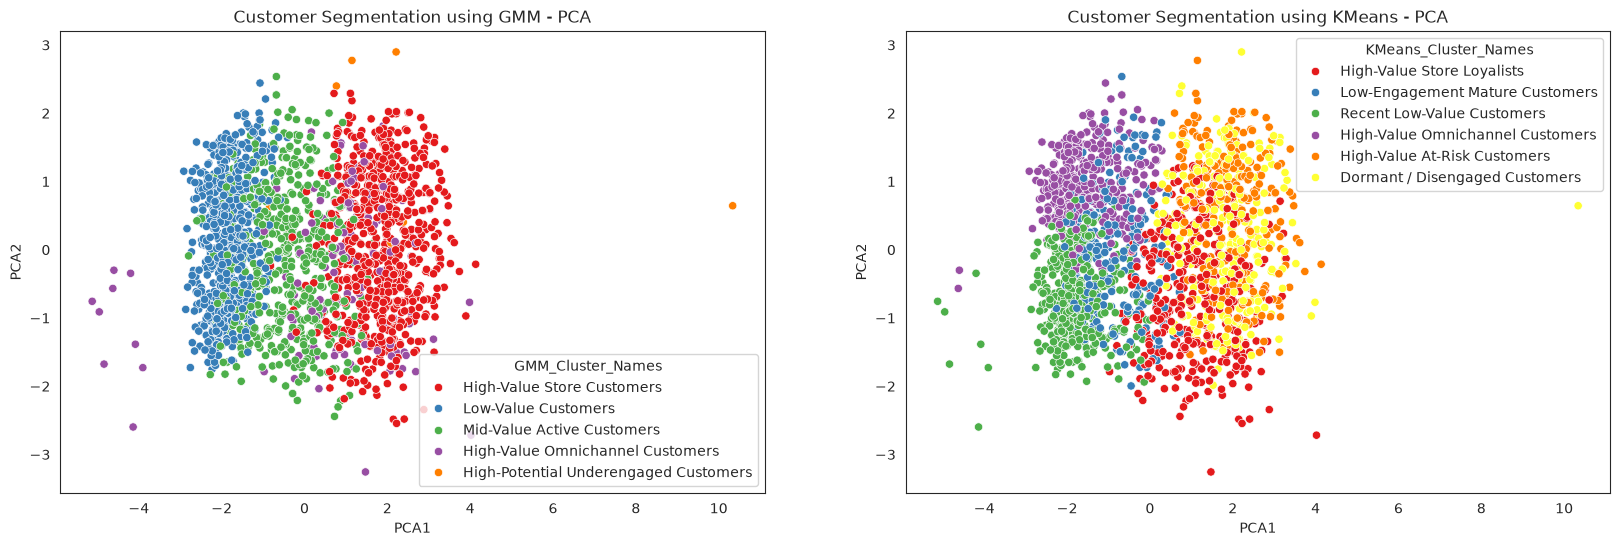

In [149]:
sns.set_style('white')
fig, axes = plt.subplots(1,2,figsize=(20,6))
fig.patch.set_alpha(0)
axes[0].patch.set_alpha(0)
axes[1].patch.set_alpha(0)
sns.scatterplot(x='PCA1', y='PCA2', hue='GMM_Cluster_Names', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Customer Segmentation using GMM - PCA')
sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster_Names', data=df, palette='Set1',ax=axes[1])
axes[1].set_title('Customer Segmentation using KMeans - PCA')
plt.savefig("kmeans_gmm_segmentation_pca.png", dpi=300, bbox_inches="tight",transparent=True
)
plt.show()

In [118]:
comparison = pd.DataFrame({
    "KMeans": {
        "Number of clusters": 6,
        "Silhouette Score": kmeans_silhouette[6],
        "Cluster assignment": "Hard assignment",
        "Membership probability": "No",
    },
    "GMM": {
        "Number of clusters": 5,
        "Silhouette Score": gmm_sil[5],
        "Cluster assignment": "Hard assignment + probabilities",
        "Membership probability": "Yes",
    }
})

comparison

,KMeans,GMM
Number of clusters,6,5
Silhouette Score,0.183261,0.097739
Cluster assignment,Hard assignment,Hard assignment + probabilities
Membership probability,No,Yes


## Saving the Model for Deployment

The clustering analysis is now complete, but the trained model can also be
used to assign new customers to the existing segments.

To use the model later through an API, the trained model and the preprocessing steps need to be saved.

It is important to preserve the same preprocessing used during training.
For example, a new customer's features must be scaled using the same scaler
that was fitted on the training data.

The trained scaler and clustering model are therefore exported using `joblib`.

In [119]:
import joblib
joblib.dump(scaler, 'scaler.pkl') # saving the standard scaler instance 
joblib.dump(kmeans, 'kmeans_model.pkl') # saving the trained KMeans model 
joblib.dump(gmm, 'GMM_model.pkl') # saving the trained GMM model

['GMM_model.pkl']

## Using a Pipeline for Deployment

In the previous section, the scaler and clustering models were saved as
separate files. This approach works, but it requires the application to load
both objects and make sure that the preprocessing is applied in the correct
order before making a prediction.

A scikit-learn `Pipeline` provides a cleaner way to handle this process. It
allows the preprocessing step and the trained clustering model to be combined
into a single object.

### KMeans Pipeline

The KMeans model can therefore be combined with `StandardScaler` into a
single pipeline.

In [120]:
from sklearn.pipeline import Pipeline

kmeans_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=6,
        random_state=42
    ))
])

kmeans_pipeline.fit(x)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','Income','Total_Spending',...,'NumStorePurchases', 'NumWebVisitsMonth','Recency']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [121]:
joblib.dump(
    kmeans_pipeline,
    "customer_segmentation_kmeans_pipeline.pkl"
)

['customer_segmentation_kmeans_pipeline.pkl']

### GMM Pipeline

The same approach can be applied to the Gaussian Mixture Model. Here, the
scaler and the five-component GMM are combined into a single pipeline.

In [122]:
gmm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gmm", GaussianMixture(
        n_components=5,
        random_state=42
    ))
])

gmm_pipeline.fit(x)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('gmm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','Income','Total_Spending',...,'NumStorePurchases', 'NumWebVisitsMonth','Recency']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [123]:
joblib.dump(
    gmm_pipeline,
    "customer_segmentation_gmm_pipeline.pkl"
)
df.to_csv('../data/data_modified.csv', index=False)

### Separate Objects vs Pipeline

The two approaches produce the same type of prediction, but they differ in
how the preprocessing and model are managed.

With separate objects, the application is responsible for loading the scaler,
transforming the new data, and then passing the transformed data to the
clustering model.

With a pipeline, these steps are encapsulated in a single object. This makes
the deployment code simpler and reduces the possibility of applying
preprocessing differently from the way it was applied during model training.

For a production application such as an API, the pipeline approach is therefore generally preferable.

## Conclusion

This project explored customer segmentation using two unsupervised learning
approaches: KMeans and Gaussian Mixture Models.

The analysis covered data exploration and preprocessing, feature selection,
model evaluation, cluster profiling, dimensionality reduction for
visualization, and comparison of the two clustering approaches.

The resulting segments provide different views of customer behavior, from
low-value and disengaged customers to high-value omnichannel and
high-potential customers. These profiles can serve as a starting point for
more targeted customer strategies and further analysis.

The trained models were also prepared for deployment using `joblib` and
scikit-learn pipelines, making it possible to integrate the segmentation
into an application such as a Streamlit dashboard or API.

## Acknowledgements

Thank you for taking the time to explore this analysis.

The dataset used in this project is the **Customer Segmentation : Clustering**
dataset available on Kaggle.